In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf 
import os
from tensorflow import keras
import numpy as np
import shutil
import warnings
from PIL import Image
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [16]:
dataset_dir = "PetImages"

for root, dirs, files in os.walk(dataset_dir):
    for f in files : 
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(root, f)
            try : 
                with Image.open(path) as img:
                    img.verify()
                with Image.open(path) as img : 
                    img = img.convert("RGB")
                    img.save(path)
            except Exception as e :
                print(f" Supprimé : {path} ({e})")
                os.remove(path)

 Supprimé : PetImages\Cat\11095.jpg ([Errno 22] Invalid argument: 'PetImages\\Cat\\11095.jpg')
 Supprimé : PetImages\Cat\12080.jpg ([Errno 22] Invalid argument: 'PetImages\\Cat\\12080.jpg')
 Supprimé : PetImages\Cat\5370.jpg ([Errno 22] Invalid argument: 'PetImages\\Cat\\5370.jpg')
 Supprimé : PetImages\Cat\6435.jpg ([Errno 22] Invalid argument: 'PetImages\\Cat\\6435.jpg')
 Supprimé : PetImages\Dog\1259.jpg ([Errno 22] Invalid argument: 'PetImages\\Dog\\1259.jpg')


In [17]:
data = keras.preprocessing.image_dataset_from_directory('PetImages',
                                                        batch_size=32,
                                                        image_size=(150,150),
                                                        label_mode='binary',
                                                        color_mode='rgb')

Found 24977 files belonging to 2 classes.


In [18]:
os.listdir('PetImages')

['Cat', 'Dog']

In [19]:
data.cardinality().numpy() *32

24992

In [20]:
class_name = data.class_names

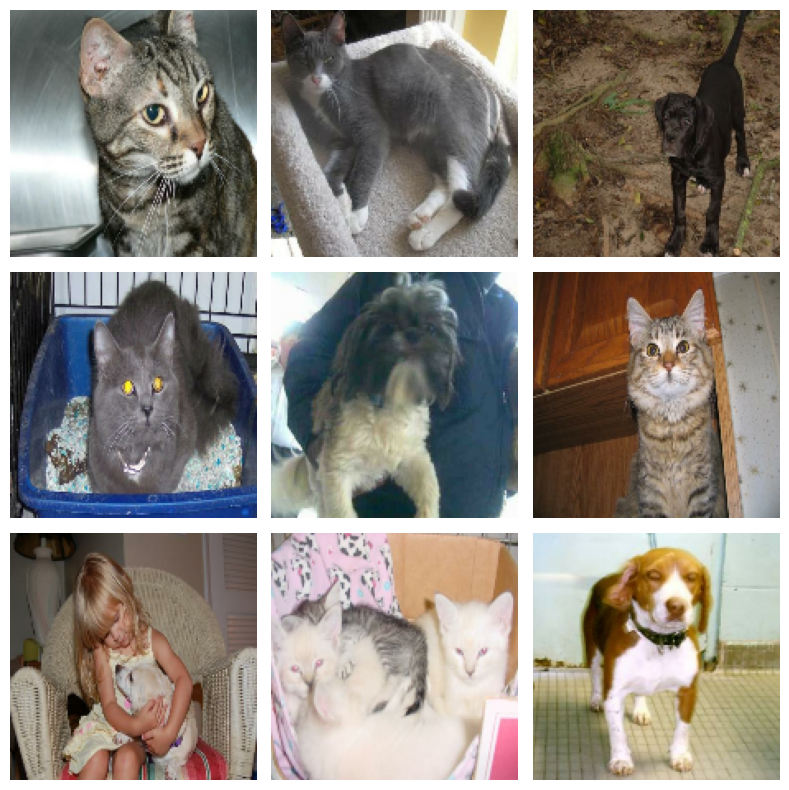

In [21]:
images, labels = next(iter(data))

fig, axes = plt.subplots(3, 3, figsize=(8,8))

idx = 0
for i in range(3):
    for j in range(3):
        axes[i,j].imshow(images[idx].numpy().astype('uint8'))
        axes[i,j].axis('off')
        idx+=1
plt.tight_layout()
plt.show()

In [22]:
train_size = int(0.75 * data.cardinality().numpy())

train_set = data.take(train_size)
val_set = data.skip(train_size)

In [23]:
model = keras.models.Sequential()

In [24]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(150,150,3), use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.Dropout(0.20),


    keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.Dropout(0.20),
    
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.30),

    keras.layers.Dense(1, activation='sigmoid')
])

In [25]:
model.compile(loss=keras.losses.binary_crossentropy,
              optimizer='adam',
              metrics=['accuracy'])

In [26]:
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

In [27]:
results = model.fit(train_set,
                    validation_data=val_set,
                    epochs=10,
                    callbacks=early_stop, 
                    batch_size=32)

Epoch 1/10
585/585 [==============================] - 1986s 3s/step - loss: 0.6408 - accuracy: 0.6331 - val_loss: 1.0444 - val_accuracy: 0.5650
Epoch 2/10
585/585 [==============================] - 1618s 3s/step - loss: 0.5538 - accuracy: 0.7192 - val_loss: 0.5926 - val_accuracy: 0.7077
Epoch 3/10
585/585 [==============================] - 1617s 3s/step - loss: 0.4982 - accuracy: 0.7649 - val_loss: 0.7101 - val_accuracy: 0.6625
Epoch 4/10
585/585 [==============================] - 1842s 3s/step - loss: 0.4353 - accuracy: 0.8013 - val_loss: 0.5507 - val_accuracy: 0.7424
Epoch 5/10
585/585 [==============================] - 1584s 3s/step - loss: 0.3695 - accuracy: 0.8399 - val_loss: 0.3887 - val_accuracy: 0.8311
Epoch 6/10
585/585 [==============================] - 1431s 2s/step - loss: 0.3051 - accuracy: 0.8739 - val_loss: 0.3925 - val_accuracy: 0.8320
Epoch 7/10
585/585 [==============================] - 1443s 2s/step - loss: 0.2652 - accuracy: 0.8881 - val_loss: 0.2973 - val_accuracy:

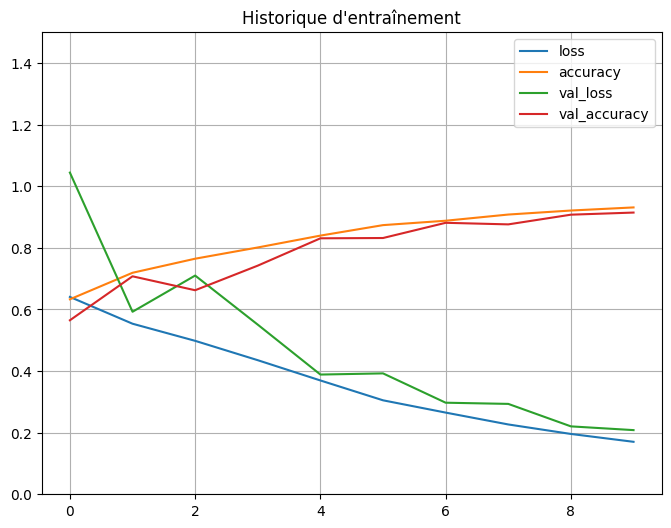

In [30]:
pd.DataFrame(results.history).plot(figsize=(8,6))
plt.grid(True)
plt.title("Historique d'entraînement")
plt.gca().set_ylim(0,1.5)
plt.show()

In [33]:
test_size = int(0.25 * data.cardinality().numpy())
test_set = val_set.take(test_size)

In [34]:
preds = model.predict(test_set)

195/195 [==============================] - 161s 736ms/step


In [37]:
y_pred = (preds > 0.5).astype(int)
y_true = []
for _, labels in test_set:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[1785 1369]
 [1683 1403]]
              precision    recall  f1-score   support

         0.0       0.51      0.57      0.54      3154
         1.0       0.51      0.45      0.48      3086

    accuracy                           0.51      6240
   macro avg       0.51      0.51      0.51      6240
weighted avg       0.51      0.51      0.51      6240



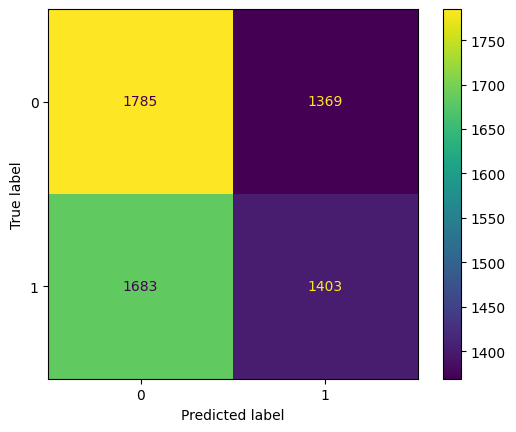

In [43]:
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()